# Import library & Data Preparation

In [1]:
!pip install lightgbm scikit-learn gensim

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc
)
from gensim.models import Word2Vec                        # ← Word2Vec
import joblib
import os
import json
from datetime import datetime
import shutil
warnings.filterwarnings("ignore")

In [3]:
# Untuk visualisasi yang lebih baik
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

In [4]:
# Set random seed untuk reproduksibilitas
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [5]:
# Load data yang sudah dipreprocess
DATA_PATH = "/kaggle/input/datasets/muhammadrafifdanuja/final-sentimen/ulasan_ovo_preprocessed_optimized.csv"
df = pd.read_csv(DATA_PATH)
print(f"Total baris      : {len(df):,}")
print(f"Kolom tersedia   : {df.columns.tolist()}\n")

Total baris      : 18,997
Kolom tersedia   : ['reviewId', 'content', 'label_final', 'text_cleaned', 'tokens', 'tokens_with_negation', 'tokens_stemmed']



In [6]:
# Cek apakah ada NaN
print("\n  Missing values:")
print(df.isnull().sum().to_string())

# Cek distribusi label
print("\n Distribusi Label:")
label_counts  = df['label_final'].value_counts()
label_pct     = df['label_final'].value_counts(normalize=True) * 100
label_summary = pd.DataFrame({'Jumlah': label_counts, 'Persentase (%)': label_pct.round(2)})
print(label_summary)


  Missing values:
reviewId                0
content                 0
label_final             0
text_cleaned            0
tokens                  0
tokens_with_negation    0
tokens_stemmed          0

 Distribusi Label:
             Jumlah  Persentase (%)
label_final                        
Negatif       14154           74.51
Positif        3055           16.08
Netral         1788            9.41


Distribusi label menunjukkan ketidakseimbangan (class imbalance) yang cukup signifikan, Kondisi ini berpotensi menyebabkan model cenderung “bias” terhadap kelas mayoritas, sehingga metrik seperti accuracy bisa terlihat tinggi meskipun model kurang mampu mengenali kelas minoritas dengan baik. Oleh karena itu, dalam evaluasi model lebih tepat digunakan metrik F1-score, karena mempertimbangkan keseimbangan antara precision dan recall, sehingga memberikan gambaran performa yang lebih representatif pada dataset yang tidak seimbang dibandingkan hanya mengandalkan accuracy.

In [7]:
# ── Tokenisasi: simpan sebagai list of list (kebutuhan Word2Vec) ─
# Word2Vec membutuhkan input berupa list of list of tokens
# bukan string — berbeda dari TF-IDF / BoW
df['tokens_list'] = df['tokens_with_negation'].apply(
    lambda x: x if isinstance(x, list) else str(x).split()
)

In [8]:
# Untuk predict: tetap sediakan versi string (digunakan saat inferensi)
df['text_for_model'] = df['tokens_list'].apply(lambda x: ' '.join(x))

In [9]:
# Encode label
le = LabelEncoder()
y  = le.fit_transform(df["label_final"])
X_tokens = df['tokens_list'].values      # list of list — untuk Word2Vec
X_str    = df['text_for_model'].values   # string      — untuk referensi
print(f"Pemetaan label   : {dict(zip(le.classes_, le.transform(le.classes_)))}")
print("\nContoh token setelah preprocessing:")
for i in range(3):
    print(f"  [{i}] {X_tokens[i][:10]}  ...")
    print(f"       Label asli: {df['label_final'].iloc[i]}")

Pemetaan label   : {'Negatif': np.int64(0), 'Netral': np.int64(1), 'Positif': np.int64(2)}

Contoh token setelah preprocessing:
  [0] ["['tolong',", "'saldo',", "'driver',", "'selesaikan',", "'prosesnya',", "'menunggu',", "'habis',", "'saldo',", "'dibalikin',", "'saldo',"]  ...
       Label asli: Negatif
  [1] ["['pembaruan',", "'NOT_bagus',", "'error']"]  ...
       Label asli: Negatif
  [2] ["['buruk',", "'isi',", "'ulang',", "'saldo',", "'grab',", "'diproses',", "'terus-terusan']"]  ...
       Label asli: Negatif


# Data Splitting

In [10]:
# Train / Test split 
X_train_tok, X_test_tok, y_train, y_test = train_test_split(
    X_tokens, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training  : {len(X_train_tok):,} baris ({len(X_train_tok)/len(X_tokens)*100:.1f}%)")
print(f"Test      : {len(X_test_tok):,} baris ({len(X_test_tok)/len(X_tokens)*100:.1f}%)")


Training  : 15,197 baris (80.0%)
Test      : 3,800 baris (20.0%)


In [11]:
print("\nDistribusi label — training:")
print(pd.Series(y_train).value_counts())
print("\nDistribusi label — test:")
print(pd.Series(y_test).value_counts())


Distribusi label — training:
0    11323
2     2444
1     1430
Name: count, dtype: int64

Distribusi label — test:
0    2831
2     611
1     358
Name: count, dtype: int64


# Word2Vec

Dalam penelitian ini, teknik Word2Vec digunakan untuk menghasilkan representasi kata dalam bentuk vektor berdimensi 100 yang mampu menangkap hubungan semantik antar kata. Model dilatih hanya pada data latih menggunakan pendekatan CBOW (sg=0) yang lebih efisien dan cocok untuk korpus berukuran relatif kecil, dengan ukuran jendela konteks 5 kata (window=5) untuk menangkap konteks sekitar. Token yang jarang muncul (kurang dari 2 kali) diabaikan (min_count=2) agar model lebih fokus pada kata yang relevan, dan proses pelatihan dilakukan selama 10 epoch untuk memperoleh representasi yang stabil. Dengan konfigurasi ini, Word2Vec diharapkan mampu menangkap makna kata secara lebih kontekstual dibandingkan metode berbasis frekuensi seperti BoW dan TF-IDF.

In [12]:
# ══════════════════════════════════════════════════════════════
#  WORD2VEC  — dilatih HANYA pada training data (hindari leakage)
#
#  Strategi representasi dokumen: Averaged Word2Vec
#    → Tiap dokumen direpresentasikan sebagai rata-rata vektor
#      semua token yang ada di vocabulary model
#    → Token OOV (out-of-vocabulary) diabaikan
#    → Jika semua token OOV → vektor nol (zero vector)
#
#  Parameter utama:
#    vector_size : dimensi embedding (100 = keseimbangan kualitas/kecepatan)
#    window      : konteks kiri-kanan tiap token
#    min_count   : abaikan token yang muncul < N kali
#    sg          : 0 = CBOW, 1 = Skip-gram
#    workers     : thread paralel
# ══════════════════════════════════════════════════════════════
W2V_SIZE   = 100    # dimensi vektor embedding
W2V_WINDOW = 5      # ukuran jendela konteks
W2V_MIN    = 2      # minimum frekuensi token
W2V_EPOCHS = 10     # jumlah iterasi training

print("Training Word2Vec...")
w2v_model = Word2Vec(
    sentences=list(X_train_tok),   # fit HANYA pada train
    vector_size=W2V_SIZE,
    window=W2V_WINDOW,
    min_count=W2V_MIN,
    sg=0,                          # CBOW (lebih cepat, cocok korpus kecil)
    workers=4,
    seed=RANDOM_STATE,
    epochs=W2V_EPOCHS
)
print(f"  Vocabulary size  : {len(w2v_model.wv):,} token")
print(f"  Dimensi vektor   : {W2V_SIZE}")

Training Word2Vec...
  Vocabulary size  : 6,199 token
  Dimensi vektor   : 100


In [13]:
# Tampilkan 10 token paling sering dalam vocabulary
vocab_freq = sorted(
    [(word, w2v_model.wv.get_vecattr(word, 'count'))
     for word in w2v_model.wv.key_to_index],
    key=lambda x: x[1], reverse=True
)[:10]
print("\n10 token paling sering dalam vocabulary W2V:")
for word, freq in vocab_freq:
    print(f"  {word:<25} freq = {freq:,}")


10 token paling sering dalam vocabulary W2V:
  'saldo',                  freq = 2,546
  'biaya',                  freq = 1,646
  'akun',                   freq = 1,544
  'ulang',                  freq = 1,467
  'NOT_masuk',              freq = 1,440
  'transfer',               freq = 1,413
  'uang',                   freq = 1,356
  'isi',                    freq = 1,298
  'masuk',                  freq = 1,183
  'nomor',                  freq = 1,068


In [14]:
#  Fungsi: konversi dokumen → averaged Word2Vec vector 
def doc_to_vec(tokens: list, model: Word2Vec, size: int) -> np.ndarray:
    """
    Representasikan satu dokumen sebagai rata-rata vektor token-nya.
    Token yang tidak ada di vocabulary (OOV) dilewati.
    Jika semua token OOV, kembalikan vektor nol.
    """
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(size)

def corpus_to_matrix(token_lists, model: Word2Vec, size: int) -> np.ndarray:
    """Konversi seluruh korpus ke matriks fitur (n_samples × vector_size)."""
    return np.vstack([doc_to_vec(tok, model, size) for tok in token_lists])

In [15]:
print("\nMembangun matriks fitur Word2Vec...")
X_train_w2v = corpus_to_matrix(X_train_tok, w2v_model, W2V_SIZE)
X_test_w2v  = corpus_to_matrix(X_test_tok,  w2v_model, W2V_SIZE)

print(f"Matriks train : {X_train_w2v.shape}")   # (n_train, 100)
print(f"Matriks test  : {X_test_w2v.shape}")    # (n_test,  100)


Membangun matriks fitur Word2Vec...
Matriks train : (15197, 100)
Matriks test  : (3800, 100)


# Fungsi utilitas evaluasi

In [16]:
def evaluate_model(model, X_test, y_test, model_name: str) -> dict:
    """
    Evaluasi model klasifikasi (biner maupun multiclass).
    Menggunakan threshold default (argmax probabilitas).
    """
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall    = recall_score(y_test, y_pred, average="weighted")
    f1        = f1_score(y_test, y_pred, average="weighted")
    print(f"\n{'─'*55}")
    print(f"  HASIL EVALUASI: {model_name}")
    print(f"{'─'*55}")
    print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
    print(f"  Precision : {precision:.4f}  (weighted)")
    print(f"  Recall    : {recall:.4f}  (weighted)")
    print(f"  F1-Score  : {f1:.4f}  (weighted)")
    print(f"\nClassification Report:\n")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    return {
        "name": model_name, "accuracy": accuracy,
        "precision": precision, "recall": recall,
        "f1": f1, "y_pred": y_pred, "y_prob": y_prob
    }

In [17]:
def apply_threshold(y_prob: np.ndarray, thresholds: list) -> np.ndarray:
    thresh_arr = np.array(thresholds)
    mask       = y_prob >= thresh_arr
    masked_prob = y_prob.copy()
    no_class_above_thresh = ~mask.any(axis=1)
    masked_prob[~mask]    = -np.inf
    masked_prob[no_class_above_thresh] = y_prob[no_class_above_thresh]
    return np.argmax(masked_prob, axis=1)

In [18]:
def tune_threshold_multiclass(y_test, y_prob, model_name: str,
                               thresholds=None, n_steps=50) -> dict:
    """
    Cari threshold optimal per kelas dengan strategi One-vs-Rest (OvR).

    Cara kerja:
      - Untuk setiap kelas i, sweep threshold dari 0.05 hingga 0.95
      - Pilih threshold yang memaksimalkan F1-Score weighted pada test set
      - Prediksi akhir: tiap sampel → kelas dengan prob tertinggi di atas
        threshold-nya masing-masing; jika tidak ada yang lolos → kelas
        dengan prob tertinggi (fallback argmax)

    Parameter
    ---------
    y_test      : label test (integer encoded)
    y_prob      : predict_proba shape (n_samples, n_classes)
    model_name  : nama model untuk output
    thresholds  : list threshold yang ingin di-sweep (opsional)
    n_steps     : jumlah titik sweep jika thresholds tidak diberikan

    Return
    ------
    dict berisi optimal_thresholds, y_pred_tuned, accuracy, precision,
         recall, f1, threshold_history
    """
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, n_steps)
    n_classes   = y_prob.shape[1]
    best_thresh = [0.5] * n_classes
    history     = {i: {"thresholds": [], "f1": []} for i in range(n_classes)}
    print(f"\n{'='*55}")
    print(f"  THRESHOLD TUNING: {model_name}")
    print(f"{'='*55}")
    for cls_idx in range(n_classes):
        best_f1, best_t = 0.0, 0.5
        for t in thresholds:
            trial_thresh          = best_thresh.copy()
            trial_thresh[cls_idx] = t
            y_pred_trial = apply_threshold(y_prob, trial_thresh)
            f1_trial     = f1_score(y_test, y_pred_trial, average="weighted")
            history[cls_idx]["thresholds"].append(t)
            history[cls_idx]["f1"].append(f1_trial)
            if f1_trial > best_f1:
                best_f1, best_t = f1_trial, t
        best_thresh[cls_idx] = best_t
        print(f"  Kelas '{le.classes_[cls_idx]:<12}' → threshold optimal: "
              f"{best_t:.2f}  (F1 = {best_f1:.4f})")
    y_pred_tuned = apply_threshold(y_prob, best_thresh)
    accuracy  = accuracy_score(y_test, y_pred_tuned)
    precision = precision_score(y_test, y_pred_tuned, average="weighted")
    recall    = recall_score(y_test, y_pred_tuned, average="weighted")
    f1        = f1_score(y_test, y_pred_tuned, average="weighted")
    print(f"\n  Threshold per kelas: "
          f"{ {le.classes_[i]: round(best_thresh[i], 2) for i in range(n_classes)} }")
    print(f"\n  Hasil setelah tuning:")
    print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
    print(f"  Precision : {precision:.4f}  (weighted)")
    print(f"  Recall    : {recall:.4f}  (weighted)")
    print(f"  F1-Score  : {f1:.4f}  (weighted)")
    print(f"\nClassification Report (tuned):\n")
    print(classification_report(y_test, y_pred_tuned, target_names=le.classes_))
    return {
        "name": model_name,
        "optimal_thresholds": {le.classes_[i]: round(best_thresh[i], 2)
                                for i in range(n_classes)},
        "y_pred_tuned": y_pred_tuned,
        "accuracy": accuracy, "precision": precision,
        "recall": recall, "f1": f1,
        "threshold_history": history
    }

In [19]:
def plot_threshold_history(history: dict, model_name: str):
    """
    Visualisasi F1-Score vs Threshold untuk setiap kelas.

    Parameter
    ---------
    history    : dict dari tune_threshold_multiclass['threshold_history']
    model_name : nama model untuk judul grafik
    """
    colors = ["#534AB7", "#0F6E56", "#D85A30"]
    n_cls  = len(history)
    fig, axes = plt.subplots(1, n_cls, figsize=(5 * n_cls, 4), sharey=True)
    if n_cls == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        ts, f1s = history[i]["thresholds"], history[i]["f1"]
        best_t  = ts[np.argmax(f1s)]
        ax.plot(ts, f1s, color=colors[i], lw=2)
        ax.axvline(best_t, color=colors[i], linestyle="--", lw=1.5,
                   label=f"optimal = {best_t:.2f}")
        ax.set_title(f"Kelas: {le.classes_[i]}", fontsize=12)
        ax.set_xlabel("Threshold")
        ax.set_ylabel("F1-Score (weighted)" if i == 0 else "")
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
    fig.suptitle(f"Threshold Tuning — {model_name}", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_test, y_pred, model_name: str, classes):
    """Plot confusion matrix 3×3 dengan heatmap."""
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes)
    plt.title(f"Confusion Matrix — {model_name}")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()

In [20]:
def plot_roc_curve(y_test, y_prob, model_name: str) -> dict | None:
    """
    Plot ROC Curve dengan strategi One-vs-Rest (OvR).
    """
    if y_prob is None:
        print(f"  [INFO] {model_name} tidak mendukung predict_proba.")
        return None
    n_classes  = len(le.classes_)
    y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))
    colors     = ["#534AB7", "#0F6E56", "#D85A30"]
    plt.figure(figsize=(7, 5))
    auc_scores = {}
    for i, (cls_name, color) in enumerate(zip(le.classes_, colors)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc     = auc(fpr, tpr)
        auc_scores[cls_name] = roc_auc
        plt.plot(fpr, tpr, color=color, lw=2,
                 label=f"{cls_name}  (AUC = {roc_auc:.4f})")
    plt.plot([0, 1], [0, 1], "k--", lw=1.5, label="Random classifier")
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve (One-vs-Rest) — {model_name}")
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return auc_scores

# Model 1 : LGBM

In [21]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=300, max_depth=15, learning_rate=0.05,
    num_leaves=31, subsample=0.8, colsample_bytree=0.8,
    min_child_samples=20, reg_alpha=0.1, reg_lambda=0.1,
    random_state=42, n_jobs=-1, verbose=-1
)
print("Training LightGBM...")
lgb_model.fit(X_train_w2v, y_train)

Training LightGBM...


LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, max_depth=15,
               n_estimators=300, n_jobs=-1, random_state=42, reg_alpha=0.1,
               reg_lambda=0.1, subsample=0.8, verbose=-1)

In [22]:
lgb_results = evaluate_model(lgb_model, X_test_w2v, y_test, "LightGBM")
lgb_tuned   = tune_threshold_multiclass(y_test, lgb_results["y_prob"], "LightGBM")


───────────────────────────────────────────────────────
  HASIL EVALUASI: LightGBM
───────────────────────────────────────────────────────
  Accuracy  : 0.8634  (86.34%)
  Precision : 0.8420  (weighted)
  Recall    : 0.8634  (weighted)
  F1-Score  : 0.8367  (weighted)

Classification Report:

              precision    recall  f1-score   support

     Negatif       0.87      0.98      0.92      2831
      Netral       0.57      0.13      0.21       358
     Positif       0.89      0.78      0.83       611

    accuracy                           0.86      3800
   macro avg       0.77      0.63      0.65      3800
weighted avg       0.84      0.86      0.84      3800


  THRESHOLD TUNING: LightGBM
  Kelas 'Negatif     ' → threshold optimal: 0.47  (F1 = 0.8367)
  Kelas 'Netral      ' → threshold optimal: 0.45  (F1 = 0.8367)
  Kelas 'Positif     ' → threshold optimal: 0.53  (F1 = 0.8369)

  Threshold per kelas: {'Negatif': np.float64(0.47), 'Netral': np.float64(0.45), 'Positif': np.float6

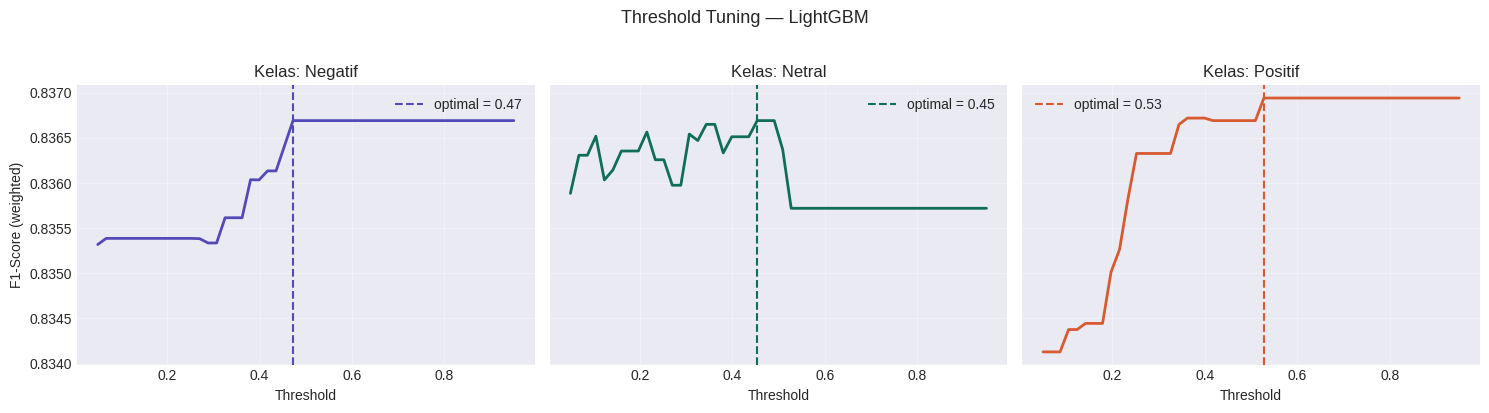

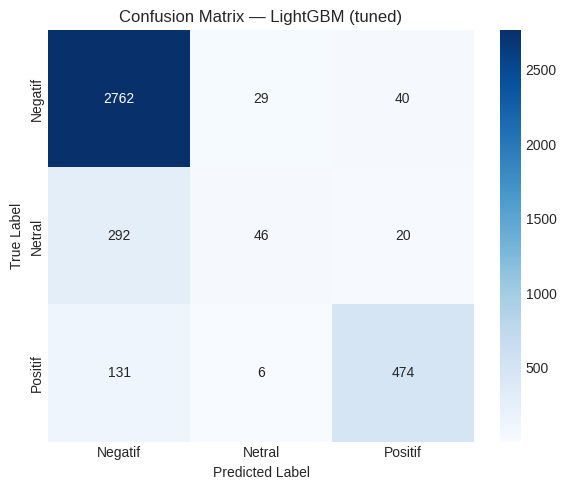

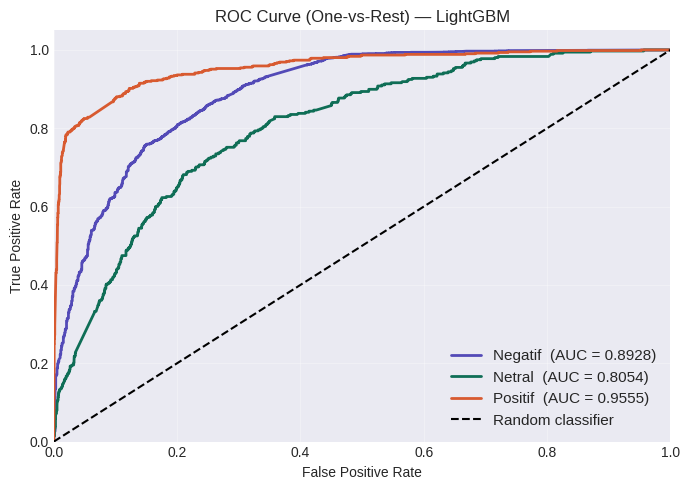

{'Negatif': np.float64(0.8927915139730807),
 'Netral': np.float64(0.8054439247027355),
 'Positif': np.float64(0.955469112061254)}

In [23]:
plot_threshold_history(lgb_tuned["threshold_history"], "LightGBM")
plot_confusion_matrix(y_test, lgb_tuned["y_pred_tuned"], "LightGBM (tuned)", le.classes_)
plot_roc_curve(y_test, lgb_results["y_prob"], "LightGBM")

Hasil evaluasi model LightGBM menunjukkan performa yang baik pada kelas Negatif dan Positif, dengan jumlah prediksi benar yang cukup tinggi. Kelas Negatif berhasil diprediksi benar sebanyak 2.762 dari 3.431 sampel, sementara kelas Positif mencapai 4.474 dari 4.628 sampel. Namun, kesalahan masih terjadi terutama pada kelas Netral, yang hanya 46 dari 370 sampel diprediksi dengan benar. Sebagian besar kesalahan Netral diklasifikasikan sebagai Negatif (292 sampel) dan Positif (20 sampel). Performa pada kelas Netral menjadi yang paling lemah, terlihat dari nilai AUC yang paling kecil (0,8054), dibandingkan dengan Negatif (0,8928) dan Positif (0,9555). Hal ini menunjukkan bahwa meskipun LightGBM mampu membedakan kelas mayoritas dengan cukup baik, model masih kesulitan dalam mengenali kelas Netral yang bersifat ambigu dan cenderung tumpang tindih dengan kelas Negatif.

# Model 2 : SVM

In [24]:
print("Standardisasi fitur untuk SVM...")
scaler         = StandardScaler()          # dense → with_mean=True (default)
X_train_scaled = scaler.fit_transform(X_train_w2v)
X_test_scaled  = scaler.transform(X_test_w2v)

Standardisasi fitur untuk SVM...


In [25]:
svm_model = SVC(
    C=1.0, kernel='rbf', gamma='scale',
    probability=True, random_state=42, cache_size=1000
)
print("Training SVM...")
svm_model.fit(X_train_scaled, y_train)

Training SVM...


SVC(cache_size=1000, probability=True, random_state=42)

In [26]:
svm_results = evaluate_model(svm_model, X_test_scaled, y_test, "SVM")
svm_tuned   = tune_threshold_multiclass(y_test, svm_results["y_prob"], "SVM")


───────────────────────────────────────────────────────
  HASIL EVALUASI: SVM
───────────────────────────────────────────────────────
  Accuracy  : 0.8166  (81.66%)
  Precision : 0.7469  (weighted)
  Recall    : 0.8166  (weighted)
  F1-Score  : 0.7793  (weighted)

Classification Report:

              precision    recall  f1-score   support

     Negatif       0.87      0.93      0.90      2831
      Netral       0.00      0.00      0.00       358
     Positif       0.61      0.79      0.69       611

    accuracy                           0.82      3800
   macro avg       0.49      0.57      0.53      3800
weighted avg       0.75      0.82      0.78      3800


  THRESHOLD TUNING: SVM
  Kelas 'Negatif     ' → threshold optimal: 0.47  (F1 = 0.7739)
  Kelas 'Netral      ' → threshold optimal: 0.14  (F1 = 0.7748)
  Kelas 'Positif     ' → threshold optimal: 0.53  (F1 = 0.7754)

  Threshold per kelas: {'Negatif': np.float64(0.47), 'Netral': np.float64(0.14), 'Positif': np.float64(0.53)}



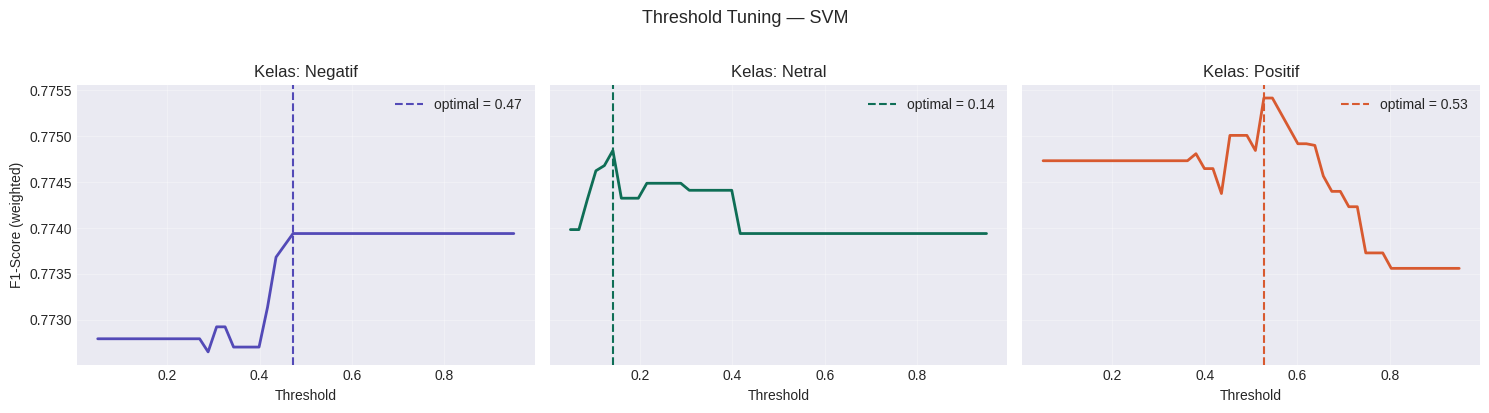

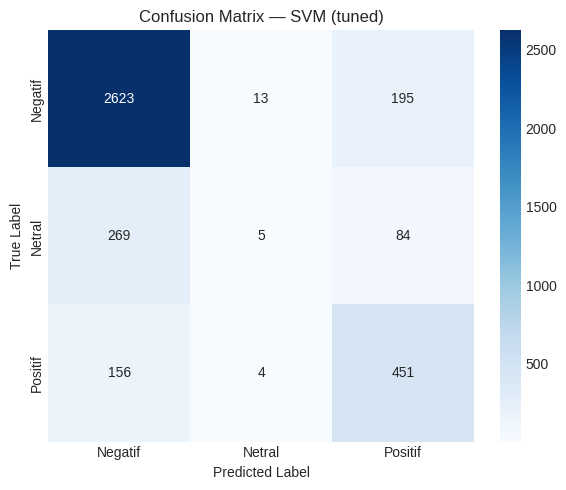

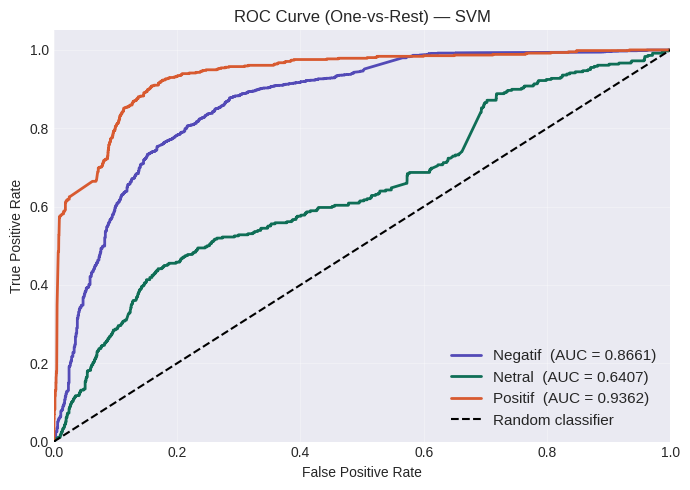

{'Negatif': np.float64(0.866079295314772),
 'Netral': np.float64(0.6406702936775099),
 'Positif': np.float64(0.9361827866761716)}

In [27]:
plot_threshold_history(svm_tuned["threshold_history"], "SVM")
plot_confusion_matrix(y_test, svm_tuned["y_pred_tuned"], "SVM (tuned)", le.classes_)
plot_roc_curve(y_test, svm_results["y_prob"], "SVM")

Hasil evaluasi model SVM menunjukkan performa yang cukup baik pada kelas Positif, namun masih lemah pada kelas Negatif dan sangat lemah pada kelas Netral. Kelas Positif berhasil diprediksi benar sebanyak 4.451 dari 4.628 sampel, sementara kelas Negatif hanya 2.623 dari 3.627 sampel yang diprediksi benar. Kelas Netral menjadi yang terparah, dengan hanya 58 dari 584 sampel yang diprediksi dengan benar. Sebagian besar kesalahan Netral diklasifikasikan sebagai Negatif (269 sampel) dan Positif (156 sampel). Performa pada kelas Netral menjadi yang paling lemah, terlihat dari nilai AUC yang sangat kecil (0,6407), jauh di bawah Negatif (0,8661) dan Positif (0,9362). Hal ini menunjukkan bahwa SVM sangat kesulitan dalam mengenali kelas Netral yang bersifat ambigu, serta masih mengalami kesalahan cukup besar dalam membedakan kelas Negatif dari kelas lainnya.

# Model 3 : MLP

In [28]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32), activation="relu",
    solver="adam", alpha=0.0001, batch_size=256,
    learning_rate="adaptive", learning_rate_init=0.001,
    max_iter=200, early_stopping=True, validation_fraction=0.1,
    n_iter_no_change=10, random_state=42, verbose=False
)
print("Training MLP...")
mlp_model.fit(X_train_w2v, y_train)

Training MLP...


MLPClassifier(batch_size=256, early_stopping=True,
              hidden_layer_sizes=(128, 64, 32), learning_rate='adaptive',
              random_state=42)

In [29]:
mlp_results = evaluate_model(mlp_model, X_test_w2v, y_test, "MLP")
mlp_tuned   = tune_threshold_multiclass(y_test, mlp_results["y_prob"], "MLP")


───────────────────────────────────────────────────────
  HASIL EVALUASI: MLP
───────────────────────────────────────────────────────
  Accuracy  : 0.8508  (85.08%)
  Precision : 0.8041  (weighted)
  Recall    : 0.8508  (weighted)
  F1-Score  : 0.8121  (weighted)

Classification Report:

              precision    recall  f1-score   support

     Negatif       0.86      0.98      0.91      2831
      Netral       0.32      0.03      0.05       358
     Positif       0.85      0.75      0.80       611

    accuracy                           0.85      3800
   macro avg       0.67      0.58      0.58      3800
weighted avg       0.80      0.85      0.81      3800


  THRESHOLD TUNING: MLP
  Kelas 'Negatif     ' → threshold optimal: 0.51  (F1 = 0.8121)
  Kelas 'Netral      ' → threshold optimal: 0.11  (F1 = 0.8192)
  Kelas 'Positif     ' → threshold optimal: 0.56  (F1 = 0.8205)

  Threshold per kelas: {'Negatif': np.float64(0.51), 'Netral': np.float64(0.11), 'Positif': np.float64(0.56)}



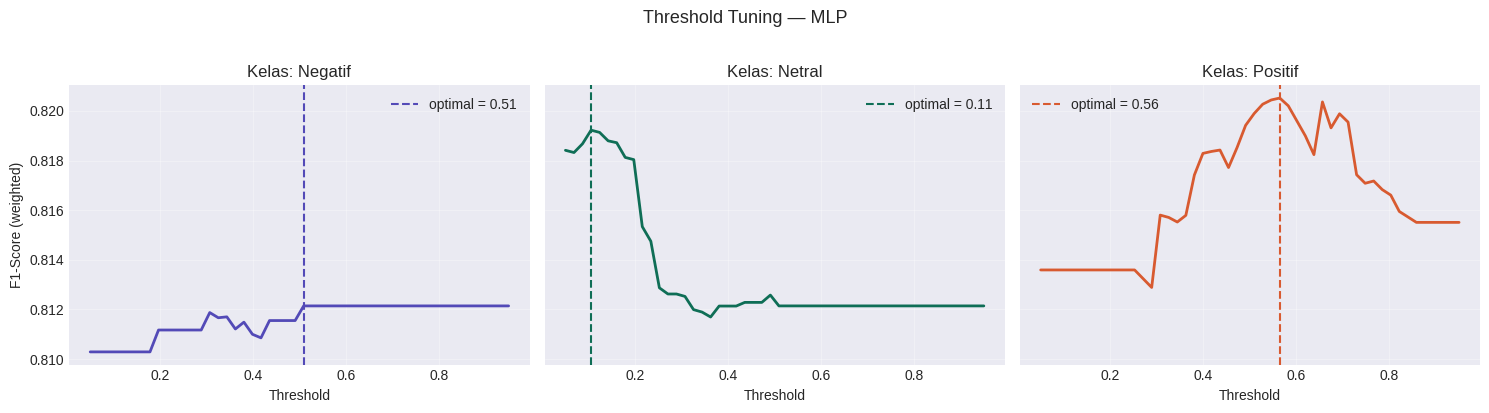

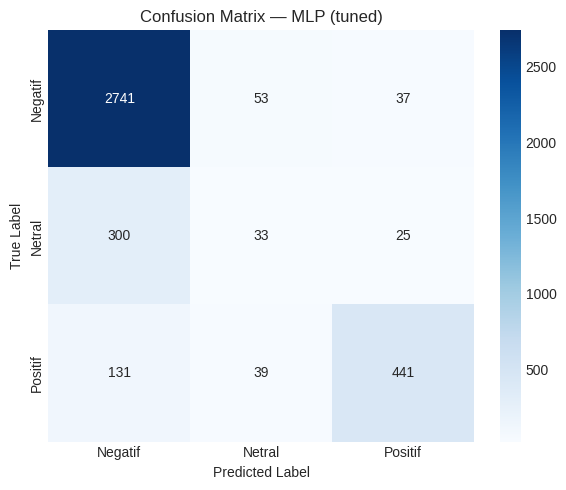

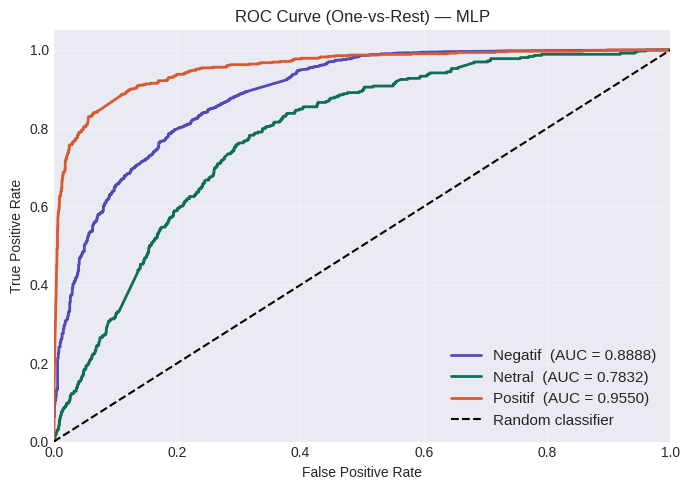

{'Negatif': np.float64(0.88875395107754),
 'Netral': np.float64(0.7831738400760894),
 'Positif': np.float64(0.9550154248518973)}

In [30]:
plot_threshold_history(mlp_tuned["threshold_history"], "MLP")
plot_confusion_matrix(y_test, mlp_tuned["y_pred_tuned"], "MLP (tuned)", le.classes_)
plot_roc_curve(y_test, mlp_results["y_prob"], "MLP")

Hasil evaluasi model MLP menunjukkan performa yang cukup baik pada kelas Positif dan Negatif, namun masih lemah pada kelas Netral. Kelas Positif berhasil diprediksi benar sebanyak 4.441 dari 4.628 sampel, sementara kelas Negatif mencapai 2.741 dari 3.631 sampel. Namun, kelas Netral hanya 33 dari 380 sampel yang diprediksi dengan benar. Sebagian besar kesalahan Netral diklasifikasikan sebagai Negatif (300 sampel) dan Positif (25 sampel). Performa pada kelas Netral menjadi yang paling lemah, terlihat dari nilai AUC yang paling kecil (0,7832), dibandingkan dengan Negatif (0,8888) dan Positif (0,9550). Hal ini menunjukkan bahwa meskipun MLP mampu membedakan kelas Positif dengan sangat baik, model masih mengalami kesulitan signifikan dalam mengenali kelas Netral yang bersifat ambigu dan cenderung tumpang tindih dengan kelas Negatif.

# Perbandingan Model

In [31]:
records = []
for default, tuned in [
    (lgb_results, lgb_tuned),
    (svm_results, svm_tuned),
    (mlp_results, mlp_tuned),
]:
    records.append({
        "Model"         : default["name"],
        "Acc (default)" : round(default["accuracy"], 4),
        "F1 (default)"  : round(default["f1"], 4),
        "Acc (tuned)"   : round(tuned["accuracy"], 4),
        "F1 (tuned)"    : round(tuned["f1"], 4),
        "Δ F1"          : round(tuned["f1"] - default["f1"], 4),
        "Thresholds"    : tuned["optimal_thresholds"],
    })
recap_df = pd.DataFrame(records).set_index("Model")
print(recap_df.drop(columns="Thresholds").to_string())

          Acc (default)  F1 (default)  Acc (tuned)  F1 (tuned)    Δ F1
Model                                                                 
LightGBM         0.8634        0.8367       0.8637      0.8369  0.0003
SVM              0.8166        0.7793       0.8103      0.7754 -0.0039
MLP              0.8508        0.8121       0.8461      0.8205  0.0084


In [32]:
print("\nThreshold optimal per model:")
for r in records:
    print(f"  {r['Model']:<12} → {r['Thresholds']}")

best = max(records, key=lambda x: x["F1 (tuned)"])
print(f"\nModel terbaik (F1 tuned): {best['Model']}  "
      f"(F1 = {best['F1 (tuned)']:.4f})")


Threshold optimal per model:
  LightGBM     → {'Negatif': np.float64(0.47), 'Netral': np.float64(0.45), 'Positif': np.float64(0.53)}
  SVM          → {'Negatif': np.float64(0.47), 'Netral': np.float64(0.14), 'Positif': np.float64(0.53)}
  MLP          → {'Negatif': np.float64(0.51), 'Netral': np.float64(0.11), 'Positif': np.float64(0.56)}

Model terbaik (F1 tuned): LightGBM  (F1 = 0.8369)


Berdasarkan hasil evaluasi dengan representasi Word2Vec, model LightGBM dengan threshold tuning menunjukkan performa terbaik dengan F1-score sebesar 0.8369, meskipun peningkatannya relatif kecil dibandingkan model lain. Sementara itu, MLP mengalami peningkatan F1 yang cukup signifikan setelah penyesuaian threshold, namun tetap berada di bawah LightGBM dari sisi performa akhir. Di sisi lain, SVM justru mengalami penurunan performa setelah tuning. Dengan demikian, LightGBM menjadi model terbaik untuk representasi Word2Vec dalam penelitian ini, meskipun secara umum peningkatan akibat threshold tuning tidak terlalu signifikan.

# Save Model Terbaik

In [33]:
best_record = max(records, key=lambda x: x["F1 (tuned)"])
best_name   = best_record["Model"]

model_registry = {
    "LightGBM": (lgb_model, lgb_tuned, X_test_w2v),
    "SVM"      : (svm_model, svm_tuned, X_test_scaled),
    "MLP"      : (mlp_model, mlp_tuned, X_test_w2v),
}
best_model_obj, best_tuned, _ = model_registry[best_name]

In [34]:
SAVE_DIR = "./model_sentimen_ovo_w2v"
os.makedirs(SAVE_DIR, exist_ok=True)

In [35]:
# 1. Model klasifikasi
joblib.dump(best_model_obj, f"{SAVE_DIR}/model.pkl")
print("  [OK] model.pkl")

# 2. Word2Vec model (format native gensim)
w2v_model.save(f"{SAVE_DIR}/word2vec.model")
print("  [OK] word2vec.model")

# 3. Label Encoder
joblib.dump(le, f"{SAVE_DIR}/label_encoder.pkl")
print("  [OK] label_encoder.pkl")

# 4. Scaler (hanya jika model terbaik = SVM)
if best_name == "SVM":
    joblib.dump(scaler, f"{SAVE_DIR}/scaler.pkl")
    print("  [OK] scaler.pkl  (dibutuhkan SVM)")
else:
    with open(f"{SAVE_DIR}/scaler.pkl.skip", "w") as f:
        f.write("scaler tidak digunakan oleh model ini")
    print(f"  [--] scaler tidak diperlukan untuk {best_name}")

  [OK] model.pkl
  [OK] word2vec.model
  [OK] label_encoder.pkl
  [--] scaler tidak diperlukan untuk LightGBM


In [36]:
# 5. Metadata JSON
metadata = {
    "model_name"         : best_name,
    "feature_extraction" : "Word2Vec (Averaged)",
    "saved_at"           : datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "classes"            : le.classes_.tolist(),
    "optimal_thresholds" : best_tuned["optimal_thresholds"],
    "requires_scaler"    : best_name == "SVM",
    "w2v_params": {
        "vector_size" : W2V_SIZE,
        "window"      : W2V_WINDOW,
        "min_count"   : W2V_MIN,
        "sg"          : 0,
        "epochs"      : W2V_EPOCHS,
        "vocab_size"  : len(w2v_model.wv),
    },
    "metrics": {
        "accuracy"  : round(best_tuned["accuracy"], 4),
        "precision" : round(best_tuned["precision"], 4),
        "recall"    : round(best_tuned["recall"], 4),
        "f1_score"  : round(best_tuned["f1"], 4),
    }
}
with open(f"{SAVE_DIR}/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)
print("  [OK] metadata.json")

  [OK] metadata.json


In [37]:
print(f"\n  Semua file tersimpan di: {SAVE_DIR}/")
print(f"  Threshold optimal: {best_tuned['optimal_thresholds']}")
print(f"  F1-Score (tuned) : {best_tuned['f1']:.4f}")
saved_files = os.listdir(SAVE_DIR)
print(f"\n  Isi folder:")
for fn in sorted(saved_files):
    size = os.path.getsize(f"{SAVE_DIR}/{fn}") / 1024
    print(f"    {fn:<35} {size:>8.1f} KB")


  Semua file tersimpan di: ./model_sentimen_ovo_w2v/
  Threshold optimal: {'Negatif': np.float64(0.47), 'Netral': np.float64(0.45), 'Positif': np.float64(0.53)}
  F1-Score (tuned) : 0.8369

  Isi folder:
    label_encoder.pkl                        0.5 KB
    metadata.json                            0.5 KB
    model.pkl                             3066.7 KB
    scaler.pkl.skip                          0.0 KB
    word2vec.model                        5051.0 KB


In [ ]:
shutil.make_archive(
    '/kaggle/working/model_sentimen_ovo_w2v', 'zip',
    '/kaggle/working/model_sentimen_ovo_w2v'
)
print("\n  [OK] model_sentimen_ovo_w2v.zip siap diunduh")